## В данном ноутбуке выполним исследовательский анализ данных (EDA)

Импортируем библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Загружаем исходные данные (наш датасет)

In [2]:
df = pd.read_csv('../raw_files/ab_testing.csv')

Посмотрим, есть ли пропуски

In [4]:
df.isnull().sum()

User ID       0
Group         0
Page Views    0
Time Spent    0
Conversion    0
Device        0
Location      0
dtype: int64

Посмотрим, есть ли дубликаты строк

In [5]:
df.duplicated().sum()

0

Проверим уникальность идентификаторов пользователей

In [8]:
df['User ID'].nunique()

5000

Преобразуем целевую переменную (Conversion) для удобства

In [ ]:
df['Conversion_binary'] = df['Conversion'].map({'Yes': 1, 'No': 0})

Сохраним очищеный файл

In [11]:
df.to_csv('../processed_files/ab_testing_processed.csv', index = False)

Проверим распределение пользователей по группам

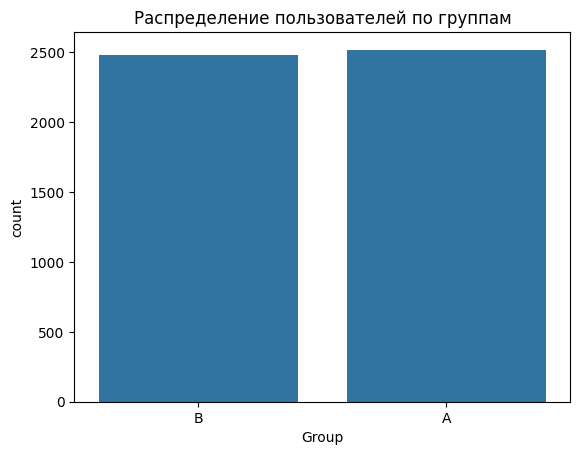

In [17]:
sns.countplot(data = df, x = 'Group')
plt.title('Распределение пользователей по группам')
plt.show()

Проверим распределение пользователей по типу устройства

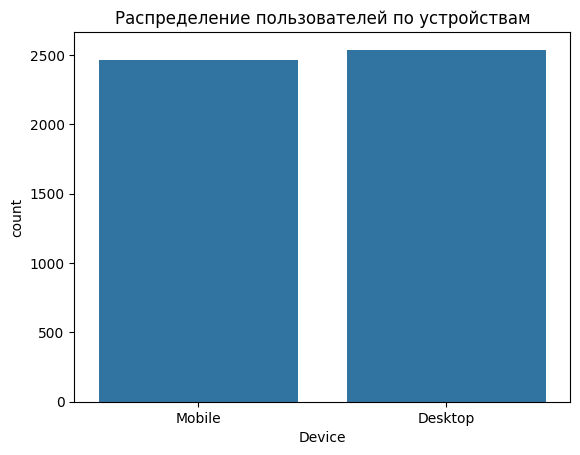

In [18]:
sns.countplot(data = df, x = 'Device')
plt.title('Распределение пользователей по устройствам')
plt.show()

Проверим распределение пользователей по локациям

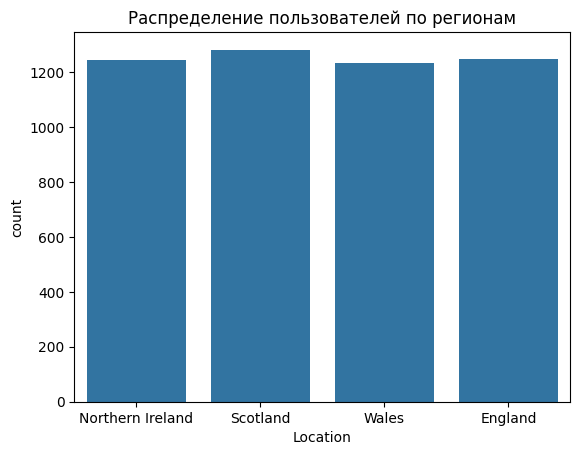

In [ ]:
sns.countplot(data = df, x = 'Location')
plt.title('Распределение пользователей по регионам')
plt.show()

Проверим распределение времени, проведённое на сайте

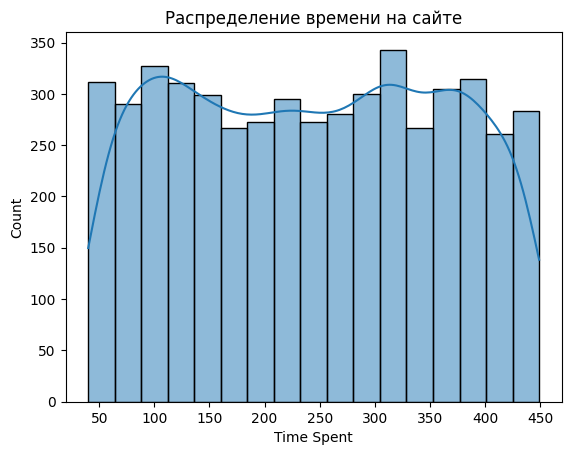

In [24]:
sns.histplot(data = df, x = 'Time Spent', kde = True)
plt.title('Распределение времени на сайте')
plt.show()

Построим Boxplot, чтобы оценить медиану, разброс и выбросы

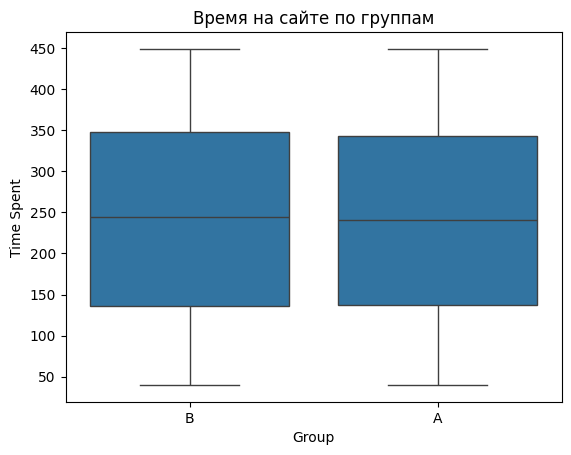

In [26]:
sns.boxplot(data = df, x = 'Group', y = 'Time Spent')
plt.title('Время на сайте по группам')
plt.show()

Проверим распределение количества просмотров страниц

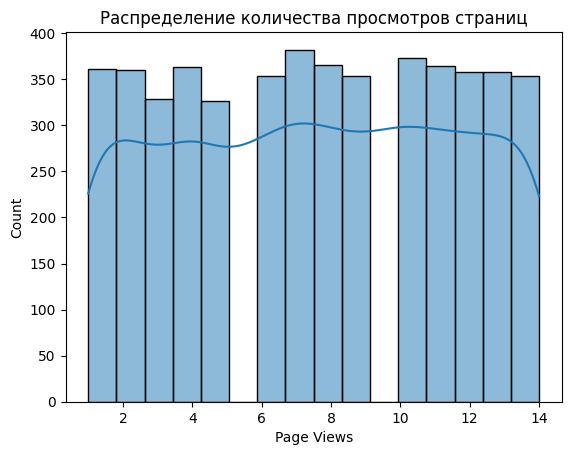

In [27]:
sns.histplot(data = df, x = 'Page Views', kde = True)
plt.title('Распределение количества просмотров страниц')
plt.show()

Посмотрим количества просмотров страниц по группам

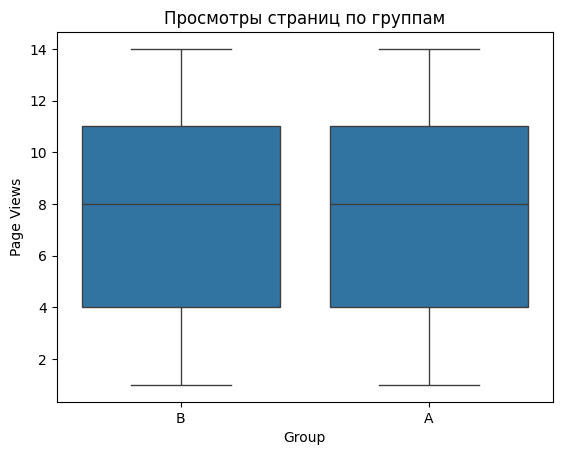

In [28]:
sns.boxplot(data = df, x = 'Group', y = 'Page Views')
plt.title('Просмотры страниц по группам')
plt.show()

Проведем корреляционный анализ числовых признаков

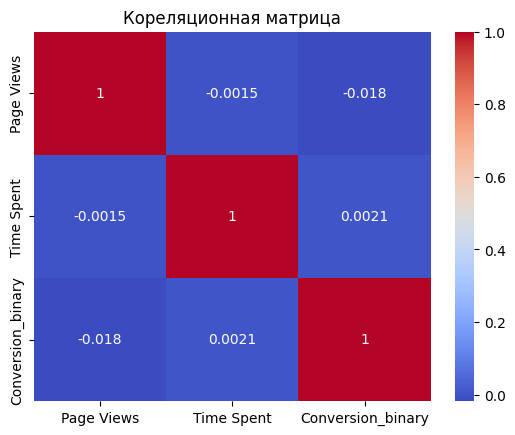

In [29]:
numeric_cols = ['Page Views', 'Time Spent', 'Conversion_binary']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title('Кореляционная матрица')
plt.show()

## Выводы

После исследовательского анализа мы выяснили:

- в данных нет пропусков и дубликатов;
- группы A и B распределены сопоставимо;
- основные метрики количественные;
- между числовыми признаками линейная связь практически отсутствует (из heatmap);
- коэффициенты корреляции между количеством просмотренных страниц, временем нахождения на сайте и конверсией близки к нулю, что указывает на слабую взаимосвязь между этими переменными в рамках текущей выборки.